# Neural Style Transfer Project

**Name:** Ashish Ashish  
**Date:** May 11, 2026  
**Topic:** Neural Style Transfer with Keras and TensorFlow

This notebook uses a pretrained VGG19 neural network to transfer the style of one image onto another image. The content image is a green sea turtle, and the style image is Hokusai's *The Great Wave off Kanagawa*.

## Step 1: Find The Pictures

### Content Picture

For the picture to stylize, I chose a green sea turtle grazing underwater. This gives the neural network a clear main subject and natural texture.

### Style Picture

For the painting style, I chose Hokusai's *The Great Wave off Kanagawa*. This image has strong blue tones, curved wave shapes, and visible line work that should transfer well to the turtle image.

In [ ]:
import os
import pathlib
import sys

project_dir = pathlib.Path.cwd()
asset_dir = project_dir / "assets_notebook"
output_dir = project_dir / "style-transfer-notebook-output"
keras_home = project_dir / ".keras"

asset_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)
keras_home.mkdir(parents=True, exist_ok=True)

os.environ["KERAS_HOME"] = str(keras_home)
os.environ["MPLCONFIGDIR"] = str(project_dir / ".matplotlib-cache")

print("Python executable:", sys.executable)
print("Project folder:", project_dir)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

In [ ]:
import urllib.request

content_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/Green_Sea_Turtle_grazing_seagrass.jpg"
style_url = "https://upload.wikimedia.org/wikipedia/commons/0/0a/The_Great_Wave_off_Kanagawa.jpg"

content_path = tf.keras.utils.get_file(
    fname="green_sea_turtle.jpg",
    origin=content_url,
    cache_dir=str(asset_dir),
    cache_subdir="",
)

# Wikimedia blocks Python's default downloader with HTTP 403, so use a browser-like User-Agent.
style_path = asset_dir / "great_wave.jpg"
if not style_path.exists():
    request = urllib.request.Request(
        style_url,
        headers={"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"},
    )
    with urllib.request.urlopen(request) as response:
        style_path.write_bytes(response.read())
style_path = str(style_path)

print("Content image:", content_path)
print("Style image:", style_path)

In [ ]:
def load_img(path_to_img, max_dim=384):
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img


def tensor_to_image(tensor):
    tensor = tensor * 255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        tensor = tensor[0]
    return tensor


def show_image(image, title=None):
    if len(image.shape) == 4:
        image = image[0]
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

In [ ]:
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
show_image(content_image, "Content Image")
plt.subplot(1, 2, 2)
show_image(style_image, "Style Image")

## Step 2: Replace `sf.jpg` And Run Style Transfer

### Smaller Test Run

The original long run can use thousands of iterations. For this notebook, I use `iterations = 200` so the code can be tested more quickly.

### Neural Network Setup

The neural network is VGG19 with pretrained ImageNet weights. The VGG19 weights are frozen. The generated image is the object being optimized.

In [ ]:
content_layers = ["block5_conv2"]
style_layers = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)


def vgg_layers(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights="imagenet")
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model


def gram_matrix(input_tensor):
    result = tf.linalg.einsum("bijc,bijd->bcd", input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
    return result / num_locations

In [ ]:
class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super().__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        inputs = inputs * 255.0
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)
        style_outputs, content_outputs = (
            outputs[: self.num_style_layers],
            outputs[self.num_style_layers :],
        )

        style_outputs = [gram_matrix(style_output) for style_output in style_outputs]

        content_dict = {
            content_name: value
            for content_name, value in zip(self.content_layers, content_outputs)
        }
        style_dict = {
            style_name: value
            for style_name, value in zip(self.style_layers, style_outputs)
        }

        return {"content": content_dict, "style": style_dict}


extractor = StyleContentModel(style_layers, content_layers)
style_targets = extractor(style_image)["style"]
content_targets = extractor(content_image)["content"]

In [ ]:
style_weight = 1e-2
content_weight = 1e4
total_variation_weight = 30

image = tf.Variable(content_image)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)


def style_content_loss(outputs):
    style_outputs = outputs["style"]
    content_outputs = outputs["content"]

    style_loss = tf.add_n(
        [tf.reduce_mean((style_outputs[name] - style_targets[name]) ** 2) for name in style_outputs]
    )
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n(
        [tf.reduce_mean((content_outputs[name] - content_targets[name]) ** 2) for name in content_outputs]
    )
    content_loss *= content_weight / num_content_layers

    return style_loss + content_loss


@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs)
        loss += total_variation_weight * tf.reduce_sum(tf.image.total_variation(image))

    grad = tape.gradient(loss, image)
    optimizer.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, 0.0, 1.0))
    return loss

In [ ]:
iterations = 200
save_every = 50

for i in range(1, iterations + 1):
    loss = train_step(image)

    if i % save_every == 0 or i == iterations:
        output_path = output_dir / f"turtle_great_wave_iteration_{i:04d}.png"
        tf.keras.utils.save_img(str(output_path), tensor_to_image(image))
        print(f"Iteration {i}: loss = {float(loss):.2f}; saved {output_path}")

final_path = output_dir / f"turtle_great_wave_iteration_{iterations:04d}.png"
print("Final image:", final_path)

In [ ]:
plt.figure(figsize=(8, 6))
show_image(image, "Green Sea Turtle Styled With The Great Wave")
plt.show()

## Research Notes

Neural style transfer was introduced by Leon A. Gatys, Alexander S. Ecker, and Matthias Bethge in the paper *A Neural Algorithm of Artistic Style*. The algorithm uses a pretrained convolutional neural network to separate content from style.

In this implementation, VGG19 is loaded with ImageNet weights using Keras. The network is used as a fixed feature extractor. Content loss keeps the generated image close to the subject image, style loss uses Gram matrices to match the painting's feature correlations, and total variation loss reduces noisy artifacts.

The generated image begins as a copy of the content image. TensorFlow's `GradientTape` computes gradients of the total loss with respect to the generated image pixels, and the optimizer updates the image until it contains both the turtle structure and the Great Wave style.

## Text-To-Image Generative AI Product Used: DALL-E 3

For the text-to-image part of the project, I used **DALL-E 3**. DALL-E 3 creates images from natural-language prompts. I used it to generate a sea turtle image in a Japanese woodblock print style with curling ocean waves.

Prompt used:

> Create a green sea turtle swimming underwater, painted in the style of a Japanese woodblock print with curling blue waves, crisp ink outlines, and dramatic ocean motion.

DALL-E 3 output:

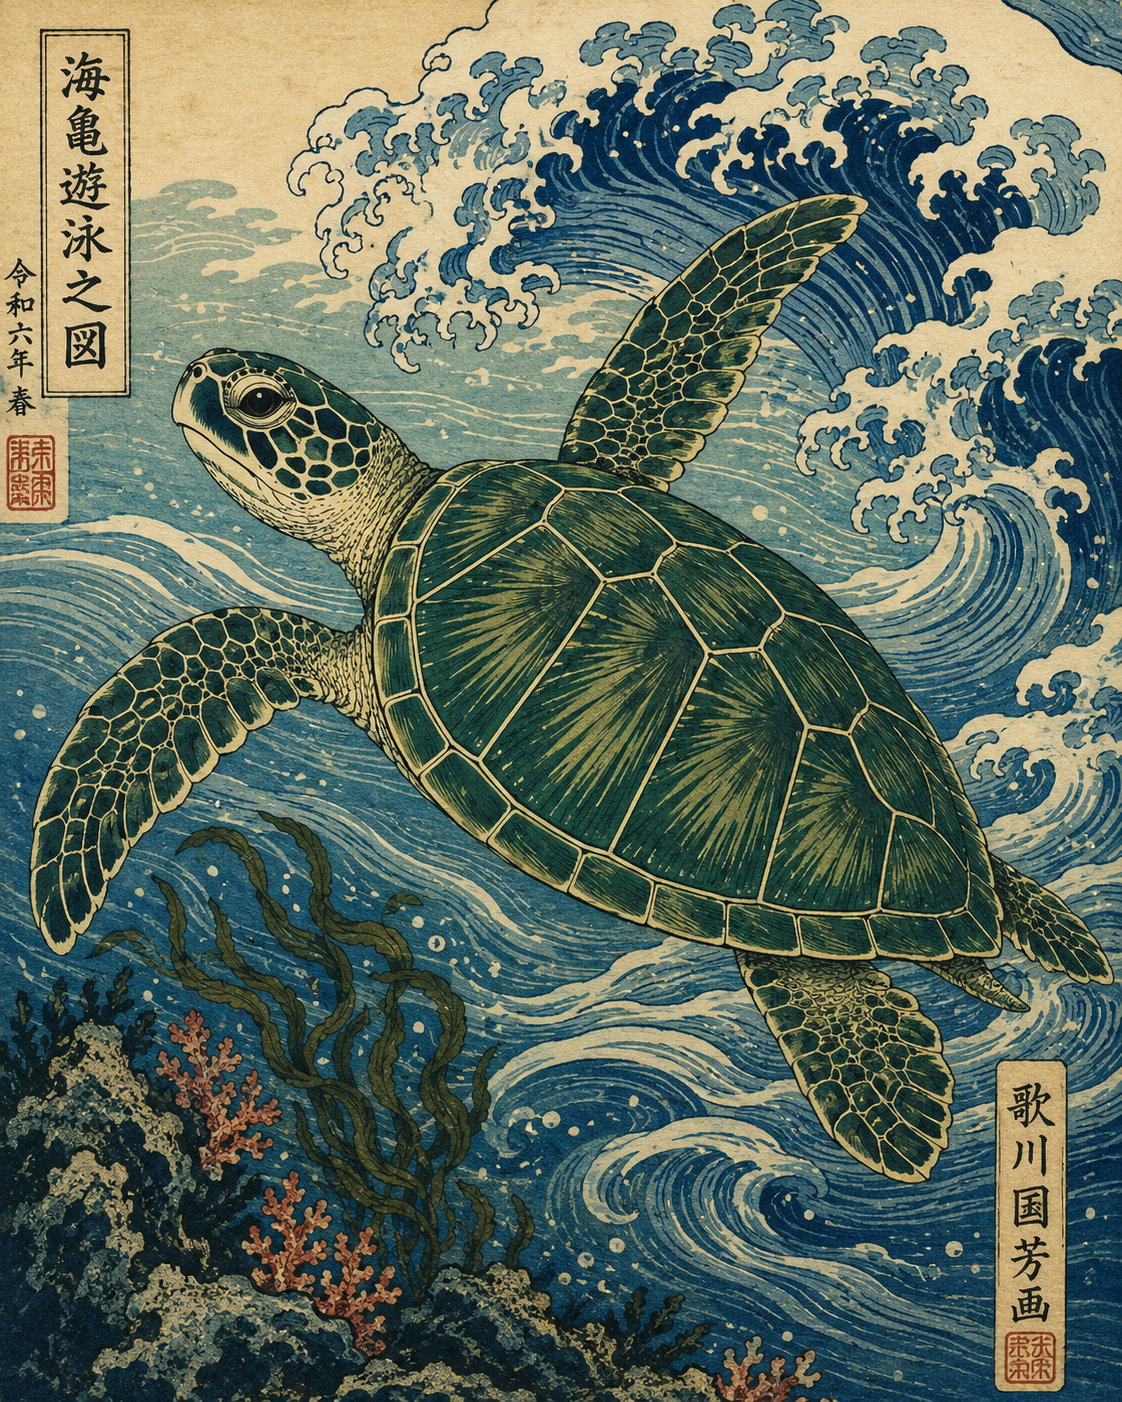

## Sources

- TensorFlow neural style transfer tutorial: https://www.tensorflow.org/tutorials/generative/style_transfer
- Gatys, Ecker, and Bethge paper: https://arxiv.org/abs/1508.06576
- OpenAI image generation docs: https://platform.openai.com/docs/guides/image-generation

## Create HTML File For Submission

Run this final cell after the style transfer cells finish. It creates a standalone HTML file with the project write-up, the neural style transfer output, and the DALL-E 3 image embedded directly in the file.

In [ ]:
import base64
import json
from html import escape

submission_html_path = project_dir / "neural_style_transfer_Ashish_Ashish_2026-05-11_submission.html"
final_style_transfer_path = output_dir / f"turtle_great_wave_iteration_{iterations:04d}.png"
dalle3_image_path = project_dir / "31e5125c-5155-46b1-bba5-01aced4d5758.png"

required_files = [
    content_path,
    style_path,
    final_style_transfer_path,
]
missing_files = [str(path) for path in required_files if not pathlib.Path(path).exists()]
if missing_files:
    raise FileNotFoundError(
        "Run all notebook cells above first. Missing files: " + ", ".join(missing_files)
    )


def image_data_uri(path, attachment_name=None):
    path = pathlib.Path(path)
    if path.exists():
        suffix = path.suffix.lower()
        mime_type = "image/png" if suffix == ".png" else "image/jpeg"
        encoded = base64.b64encode(path.read_bytes()).decode("ascii")
        return f"data:{mime_type};base64,{encoded}"

    if attachment_name is not None:
        notebook_path = project_dir / "neural_style_transfer_Ashish_Ashish_2026-05-11.ipynb"
        notebook_data = json.loads(notebook_path.read_text(encoding="utf-8"))
        for cell in notebook_data["cells"]:
            attachment = cell.get("attachments", {}).get(attachment_name)
            if attachment:
                mime_type, encoded = next(iter(attachment.items()))
                return f"data:{mime_type};base64,{encoded}"

    raise FileNotFoundError(f"Image not found and no notebook attachment fallback was available: {path}")


content_uri = image_data_uri(content_path)
style_uri = image_data_uri(style_path)
final_uri = image_data_uri(final_style_transfer_path)
dalle3_uri = image_data_uri(dalle3_image_path, attachment_name="dalle3_sea_turtle.png")

html_document = f"""
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Neural Style Transfer Project - Ashish Ashish</title>
  <style>
    body {{ font-family: Arial, sans-serif; line-height: 1.55; max-width: 1000px; margin: 40px auto; padding: 0 24px; color: #1f2933; }}
    h1, h2, h3 {{ color: #0f172a; }}
    .meta {{ color: #475569; margin-bottom: 28px; }}
    .image-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(260px, 1fr)); gap: 18px; margin: 18px 0 28px; }}
    figure {{ margin: 0; border: 1px solid #d7dee8; padding: 12px; border-radius: 8px; background: #ffffff; }}
    img {{ width: 100%; height: auto; display: block; border-radius: 4px; }}
    figcaption {{ font-size: 0.92rem; color: #52606d; margin-top: 8px; }}
    code, pre {{ background: #f3f6f9; border-radius: 4px; }}
    code {{ padding: 2px 4px; }}
    blockquote {{ border-left: 4px solid #7aa2c7; margin-left: 0; padding-left: 16px; color: #334e68; }}
  </style>
</head>
<body>
  <h1>Neural Style Transfer Project</h1>
  <p class="meta"><strong>Name:</strong> Ashish Ashish<br><strong>Date:</strong> May 11, 2026<br><strong>Topic:</strong> Neural Style Transfer with Keras and TensorFlow</p>

  <h2>Step 1: Find The Pictures</h2>
  <p>For the content picture, I chose a green sea turtle grazing underwater. For the painting style, I chose Hokusai's <em>The Great Wave off Kanagawa</em>, which has strong blue tones, curved wave shapes, and visible line work.</p>
  <div class="image-grid">
    <figure><img src="{content_uri}" alt="Green sea turtle content image"><figcaption>Content image: green sea turtle.</figcaption></figure>
    <figure><img src="{style_uri}" alt="Great Wave style image"><figcaption>Style image: Hokusai's <em>The Great Wave off Kanagawa</em>.</figcaption></figure>
  </div>

  <h2>Step 2: Replace sf.jpg And Run Style Transfer</h2>
  <p>I replaced the original <code>sf.jpg</code> image with the green sea turtle image and used <code>iterations = 200</code> for a smaller test run. The neural network is VGG19 with pretrained ImageNet weights. VGG19 is used as a fixed feature extractor, and the generated image pixels are optimized with TensorFlow.</p>
  <figure><img src="{final_uri}" alt="Final neural style transfer output"><figcaption>Final neural style transfer output after 200 iterations.</figcaption></figure>

  <h2>Research Notes</h2>
  <p>Neural style transfer was introduced by Leon A. Gatys, Alexander S. Ecker, and Matthias Bethge in the paper <em>A Neural Algorithm of Artistic Style</em>. The algorithm uses a pretrained convolutional neural network to separate content from style.</p>
  <p>Content loss keeps the generated image close to the subject image, style loss uses Gram matrices to match the painting's feature correlations, and total variation loss reduces noisy artifacts. TensorFlow's <code>GradientTape</code> computes gradients of the total loss with respect to the generated image pixels.</p>

  <h2>Text-To-Image Generative AI Product Used: DALL-E 3</h2>
  <p>For the text-to-image part of the project, I used <strong>DALL-E 3</strong>. DALL-E 3 creates images from natural-language prompts. I used it to generate a sea turtle image in a Japanese woodblock print style with curling ocean waves.</p>
  <p><strong>Prompt used:</strong></p>
  <blockquote>Create a green sea turtle swimming underwater, painted in the style of a Japanese woodblock print with curling blue waves, crisp ink outlines, and dramatic ocean motion.</blockquote>
  <figure><img src="{dalle3_uri}" alt="DALL-E 3 generated sea turtle image"><figcaption>DALL-E 3 generated image.</figcaption></figure>

  <h2>Sources</h2>
  <ul>
    <li>TensorFlow neural style transfer tutorial: https://www.tensorflow.org/tutorials/generative/style_transfer</li>
    <li>Gatys, Ecker, and Bethge paper: https://arxiv.org/abs/1508.06576</li>
    <li>OpenAI image generation docs: https://platform.openai.com/docs/guides/image-generation</li>
  </ul>
</body>
</html>
"""

submission_html_path.write_text(html_document, encoding="utf-8")
print(f"Created submission HTML: {submission_html_path}")